In [1]:
%matplotlib inline
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

# Columns mirror a slimmed-down Avazu schema. The first few are high-cardinality
# (like site_id / app_id / device_id); the rest are low-cardinality context.
CARD = {
    "site_id": 1500, "app_id": 1200, "device_id": 6000,
    "site_category": 22, "app_category": 18,
    "device_type": 5, "banner_pos": 4, "hour": 24,
}
CAT_COLS = list(CARD)


def _calibrate_bias(logit, target):
    lo, hi = -20.0, 20.0
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if sigmoid(logit + mid).mean() < target:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


def make_ctr_data(n=30000, target_ctr=0.17, seed=0):
    """Synthetic click-through data that mimics the Avazu schema.

    Click probability is driven by per-value latent weights plus one
    category interaction, then the intercept is calibrated so the overall
    click rate is ~target_ctr (a realistically imbalanced problem).
    Returns a DataFrame of string categorical columns plus a 0/1 `click`.
    """
    g = np.random.default_rng(seed)
    # a few columns carry more signal than others
    scale = {"site_id": 0.5, "app_id": 0.5, "device_id": 0.2, "site_category": 0.8,
             "app_category": 0.7, "device_type": 0.4, "banner_pos": 0.6, "hour": 0.3}
    latent = {c: g.normal(0, scale[c], size=CARD[c]) for c in CAT_COLS}
    vals = {c: g.integers(0, CARD[c], size=n) for c in CAT_COLS}

    logit = np.zeros(n)
    for c in CAT_COLS:
        logit += latent[c][vals[c]]
    # interaction: certain (site_category, device_type) pairs click more
    inter = g.normal(0, 0.7, size=(CARD["site_category"], CARD["device_type"]))
    logit += inter[vals["site_category"], vals["device_type"]]

    logit += _calibrate_bias(logit, target_ctr)
    click = (g.random(n) < sigmoid(logit)).astype(int)
    df = pd.DataFrame({c: [f"{c}_{v}" for v in vals[c]] for c in CAT_COLS})
    df["click"] = click
    return df


df = make_ctr_data(n=30000, target_ctr=0.17, seed=0)
print("rows:", len(df), "| click rate:", round(df['click'].mean(), 3))
print("unique device_id values:", df['device_id'].nunique())
df.head()

# ---------------------------------------------------------------------------
# To use the REAL data instead, accept the Avazu competition on Kaggle, then:
#     df = pd.read_csv("train.gz", nrows=300_000)
#     df = df.rename(columns={"click": "click"})  # already named `click`
# Keep CAT_COLS to the categorical columns you want to hash; everything below
# works unchanged on the real frame.
# ---------------------------------------------------------------------------


def train_test_split(df, test_size=0.3, seed=123):
    idx = np.arange(len(df))
    np.random.default_rng(seed).shuffle(idx)
    n_test = int(round(test_size * len(df)))
    return df.iloc[idx[n_test:]].reset_index(drop=True), df.iloc[idx[:n_test]].reset_index(drop=True)


train_df, test_df = train_test_split(df)
y_train = train_df["click"].to_numpy()
y_test = test_df["click"].to_numpy()
len(train_df), len(test_df)

def hash_row(row, cols, D):
    """Return the list of active bucket indices for one row (the hashing trick).

    For each column build a stable token like "site_id=site_id_42", hash it to
    an integer in [0, D), and collect those indices. Use a deterministic hash
    (hashlib), NOT Python's built-in hash() which is salted per process.
    """
    if D <= 0:
      raise ValueError("D must be a positive integer")

    indices = []
    for col in cols:
        token = f"{col}={row[col]}"
        digest = hashlib.sha256(token.encode("utf-8")).digest()
        bucket = int.from_bytes(digest, byteorder="big") % D
        indices.append(bucket)

    return indices

def build_index_matrix(frame, cols, D):
    """Apply hash_row to every row -> int array of shape (n, len(cols))."""
    return np.array([hash_row(r, cols, D) for _, r in frame.iterrows()], dtype=np.int64)

rows: 30000 | click rate: 0.17
unique device_id values: 5957


### Gradient derivation

For one training example,

$$
z = \mathbf{w}^\top \mathbf{x} + b,
\qquad
p = \sigma(z) = \frac{1}{1+e^{-z}},
$$

and the binary cross-entropy loss is

$$
\ell = -\left[y\log(p) + (1-y)\log(1-p)\right].
$$

First differentiate the loss with respect to $p$:

$$
\frac{\partial \ell}{\partial p}
= -\frac{y}{p} + \frac{1-y}{1-p}.
$$

The derivative of the sigmoid is

$$
\frac{\partial p}{\partial z} = p(1-p).
$$

Using the chain rule,

$$
\frac{\partial \ell}{\partial z}
= \frac{\partial \ell}{\partial p}
  \frac{\partial p}{\partial z}
= \left(-\frac{y}{p} + \frac{1-y}{1-p}\right)p(1-p)
= p-y.
$$

Because

$$
\frac{\partial z}{\partial \mathbf{w}} = \mathbf{x}
\qquad\text{and}\qquad
\frac{\partial z}{\partial b} = 1,
$$

the gradients are

$$
\boxed{\frac{\partial \ell}{\partial \mathbf{w}}=(p-y)\mathbf{x}}
\qquad\text{and}\qquad
\boxed{\frac{\partial \ell}{\partial b}=p-y}.
$$

With learning rate $\eta$, one SGD update is therefore

$$
\mathbf{w} \leftarrow \mathbf{w}-\eta(p-y)\mathbf{x},
\qquad
b \leftarrow b-\eta(p-y).
$$

For the hashed representation, $\mathbf{x}$ is sparse: only the buckets produced by the categorical features are active. Therefore, the model does not need to update all $D$ weights. For every active bucket $j$,

$$
w_j \leftarrow w_j-\eta(p-y)x_j,
$$

while every inactive weight remains unchanged. Normally $x_j=1$, so each active weight receives the update $-\eta(p-y)$. If two fields from the same example hash to the same bucket, that bucket has multiplicity $x_j>1$ and must receive the update once for each occurrence, equivalently $-\eta(p-y)x_j$. The bias is updated once per example.


In [2]:

def train_logreg_sgd(X_idx, y, D, lr=0.1, epochs=3, l2=1e-6, seed=0):
    """From-scratch SGD logistic regression over hashed features.

    Maintain a weight vector w of length D and a bias b. For each example the
    logit is b + sum of w over the row's active buckets. Use the gradient you
    derived in Task 2 to update ONLY the active weights (plus the bias), with
    optional L2 shrinkage. Return (w, b).
    """
    w = np.zeros(D)
    b = 0.0

    rng = np.random.default_rng(seed)
    n = len(y)

    for _ in range(epochs):
      order = rng.permutation(n)

      for i in order:
            idx = X_idx[i]

            z = b + w[idx].sum()
            p = sigmoid(z)

            g = p - y[i]

            for j in idx:
                w[j] -= lr * (g + l2 * w[j])

            b -= lr * g

    return w, b

def predict_proba(X_idx, w, b):
    """Vectorized probabilities: sigmoid(b + sum of active weights)."""
    return sigmoid(b + w[X_idx].sum(axis=1))

baseline log-loss (predict the base rate 0.171): 0.4503
model log-loss:    0.4106
model avg precision (PR-AUC): 0.3459
positives in test: 0.166  (so 'always no-click' has 0.834 accuracy)


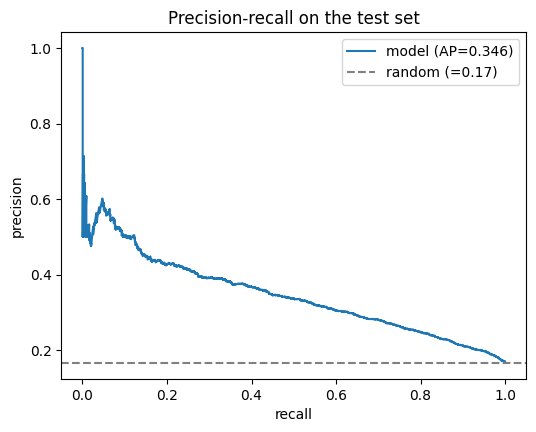

In [4]:
def log_loss(y, p, eps=1e-12):
    """Mean binary cross-entropy."""
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def pr_curve(y, p):
    """Return (recall, precision) arrays by sweeping the threshold from high
    score to low (sort by descending p and accumulate TP/FP)."""
    order = np.argsort(-p)
    y_sorted = y[order]

    tp = np.cumsum(y_sorted)
    fp = np.cumsum(1 - y_sorted)

    precision = tp / (tp + fp)

    total_positives = np.sum(y)
    if total_positives == 0:
        recall = np.zeros_like(precision, dtype=float)
    else:
        recall = tp / total_positives

    recall = np.concatenate(([0.0], recall))
    precision = np.concatenate(([1.0], precision))

    return recall, precision


def average_precision(y, p):
    """Area under the precision-recall curve (integrate precision over recall)."""
    recall, precision = pr_curve(y, p)
    return np.sum((recall[1:] - recall[:-1]) * precision[1:])


D = 2 ** 18
Xtr = build_index_matrix(train_df, CAT_COLS, D)
Xte = build_index_matrix(test_df, CAT_COLS, D)
w, b = train_logreg_sgd(Xtr, y_train, D, lr=0.1, epochs=3)

p_te = predict_proba(Xte, w, b)
base_rate = y_train.mean()
print(f"baseline log-loss (predict the base rate {base_rate:.3f}): "
      f"{log_loss(y_test, np.full_like(p_te, base_rate)):.4f}")
print(f"model log-loss:    {log_loss(y_test, p_te):.4f}")
print(f"model avg precision (PR-AUC): {average_precision(y_test, p_te):.4f}")
print(f"positives in test: {y_test.mean():.3f}  (so 'always no-click' has {1-y_test.mean():.3f} accuracy)")

rec, prec = pr_curve(y_test, p_te)
plt.figure(figsize=(6, 4.5))
plt.plot(rec, prec, label=f"model (AP={average_precision(y_test, p_te):.3f})")
plt.axhline(y_test.mean(), ls="--", c="grey", label=f"random (={y_test.mean():.2f})")
plt.xlabel("recall"); plt.ylabel("precision")
plt.title("Precision-recall on the test set"); plt.legend()
plt.show()

D=2^ 8  AP=0.267  logloss=0.4417
D=2^10  AP=0.296  logloss=0.4420
D=2^12  AP=0.321  logloss=0.4306
D=2^14  AP=0.332  logloss=0.4183
D=2^16  AP=0.343  logloss=0.4116
D=2^18  AP=0.346  logloss=0.4106


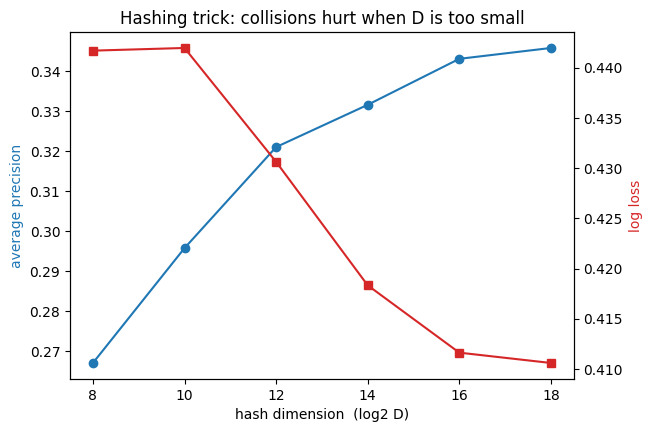

In [6]:
# Centerpiece: how does the hash dimension D trade memory against collisions?
Ds = [2 ** 8, 2 ** 10, 2 ** 12, 2 ** 14, 2 ** 16, 2 ** 18]
ap_by_D, ll_by_D = [], []
for Dk in Ds:
  Xtr_k = build_index_matrix(train_df, CAT_COLS, Dk)
  Xte_k = build_index_matrix(test_df, CAT_COLS, Dk)

  w_k, b_k = train_logreg_sgd(
        Xtr_k,
        y_train,
        Dk,
        lr=0.1,
        epochs=3
    )

  p_te_k = predict_proba(Xte_k, w_k, b_k)

  ap_by_D.append(average_precision(y_test, p_te_k))
  ll_by_D.append(log_loss(y_test, p_te_k))

for Dk, ap, ll in zip(Ds, ap_by_D, ll_by_D):
    print(f"D=2^{int(np.log2(Dk)):>2}  AP={ap:.3f}  logloss={ll:.4f}")


fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
xs = [int(np.log2(d)) for d in Ds]
ax1.plot(xs, ap_by_D, "-o", color="tab:blue")
ax1.set_xlabel("hash dimension  (log2 D)")
ax1.set_ylabel("average precision", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(xs, ll_by_D, "-s", color="tab:red")
ax2.set_ylabel("log loss", color="tab:red")
plt.title("Hashing trick: collisions hurt when D is too small")
plt.show()

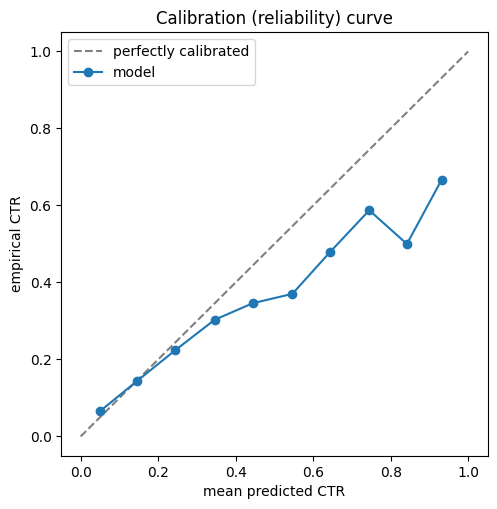

In [7]:
def reliability_curve(y, p, n_bins=10):
    """Bin predictions into n_bins equal-width probability bins; return
    (mean_predicted, empirical_rate) per non-empty bin."""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(p, bin_edges[1:-1])

    mean_predicted = []
    empirical_rate = []

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id

        if np.any(mask):
            mean_predicted.append(np.mean(p[mask]))
            empirical_rate.append(np.mean(y[mask]))

    return np.array(mean_predicted), np.array(empirical_rate)

mp, emp = reliability_curve(y_test, p_te, n_bins=10)
plt.figure(figsize=(5.5, 5.5))
plt.plot([0, 1], [0, 1], "--", c="grey", label="perfectly calibrated")
plt.plot(mp, emp, "-o", label="model")
plt.xlabel("mean predicted CTR"); plt.ylabel("empirical CTR")
plt.title("Calibration (reliability) curve"); plt.legend()
plt.show()



1. The click rate is ~17%. What accuracy does the trivial "always predict no-click" model get, and why is accuracy the wrong headline metric here? Why are log-loss, average precision, and the PR curve more informative?

The dataset has a click rate of about 17%, so an "always predict no-click" model would achieve approximately 83% accuracy because it correctly predicts every non-click. Although this accuracy appears high, the model completely fails to identify any clicks, making it ineffective for CTR prediction. Accuracy is therefore a poor metric for imbalanced datasets. Log-loss is more informative because it measures the quality of the predicted probabilities and heavily penalizes confident incorrect predictions. Average precision and the precision-recall curve focus on performance for the positive class, making them much better measures of how well the model identifies the rare events that matter.


2. The hashing trick replaces one-hot encoding of high-cardinality IDs. What do you gain (memory, handling unseen values at test time) and what do you lose (collisions)? From your D sweep, where does shrinking D start to hurt, and why?

The hashing trick replaces one-hot encoding by mapping categorical values into a fixed number of hash buckets instead of creating a separate feature for every unique category. This greatly reduces memory usage and allows the model to handle unseen values at test time because new feature values are simply hashed into one of the existing buckets. The tradeoff is hash collisions, where different feature values map to the same bucket and must share a weight, making it harder for the model to distinguish between them. From the D sweep, performance improves steadily as D increases. Average precision rises from 0.267 at 2⁸ to 0.346 at 2¹⁸, while log-loss decreases from 0.4417 to 0.4106. The largest improvements occur between 2⁸ and 2¹⁴, showing that shrinking D below about 2¹⁴ begins to noticeably hurt performance. This happens because smaller hash tables create many more collisions, causing unrelated features to share weights and reducing the model's predictive accuracy.

3. Restate the gradient you derived and explain why a hashed example updates only a handful of weights. Why does that make this model scale to billions of features?

The gradient of the loss with respect to the weights is (p − y)x, while the gradient with respect to the bias is (p − y). During stochastic gradient descent, only the weights corresponding to the active hashed feature indices are updated because all other features have a value of zero. Since each training example contains only a small number of active hashed features, each update modifies only a handful of weights rather than the entire parameter vector. This sparse update makes both the computation and memory requirements very small, allowing logistic regression with feature hashing to scale efficiently even when the total feature space contains billions of possible features.


4. Read your calibration curve. Are the predicted probabilities calibrated? Why does ad ranking/bidding (which multiplies predicted CTR by a bid) need calibrated probabilities, not just a good ranking?

The calibration curve shows that the model is reasonably calibrated at low predicted CTR values but becomes less well calibrated as the predicted probabilities increase. Most of the points at moderate and high predicted CTRs lie below the diagonal, indicating that the model generally overestimates the true probability of a click. Calibration is important for ad ranking because advertisers often rank ads using the predicted CTR multiplied by the bid amount. If the predicted probabilities are not well calibrated, the expected value of an ad can be overestimated or underestimated, leading to less effective ranking and bidding decisions, even if the model orders ads reasonably well.

5. Name one way to handle the class imbalance (class weights, threshold tuning, negative downsampling, ...). How would it move the PR curve and the calibration?

One common approach is to use class weights, giving greater importance to the minority (clicked) class during training. This encourages the model to identify more positive examples and often improves recall, which can improve the precision-recall curve. However, increasing the emphasis on positive examples may also make the predicted probabilities less well calibrated because the model is trained under a modified class distribution. As a result, additional calibration methods may be needed if accurate probability estimates are important.